# 04 SVM Aspect Classification

Finalization notebook for Phase 9C. This notebook documents the SVM aspect-classifier decision and candidate AHP/Fuzzy AHP criteria. It is read-only: it does not retrain SVM, fit TF-IDF, or create model artifacts.


## CRISP-DM Stage

Model evaluation and transition to decision-support design. The selected SVM scenario is finalized so the project can proceed to AHP/Fuzzy AHP criteria and expert judgement design.


## SVM Role in SentiRank

SVM is used for aspect classification, not sentiment classification. IndoBERT `run_3_weighted_loss_lr_1e-5` remains the final sentiment classifier candidate. The SVM aspect classifier converts review text into actionable issue categories that can support priority-ranking criteria after expert validation.


## Weak Label Limitation

The SVM aspect classifier was trained and evaluated on weak labels derived from keyword-based aspect labeling. Therefore, the evaluation reflects the model's ability to learn weak-label patterns, not expert-validated ground truth.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "CLAUDE.md").exists() and (candidate / "ml-service").exists():
            return candidate
    raise RuntimeError("Could not find SentiRank project root from current working directory.")


PROJECT_ROOT = find_project_root()
EDA04_DIR = PROJECT_ROOT / "datasets" / "outputs" / "eda" / "04_svm"
FIG04_DIR = PROJECT_ROOT / "docs" / "figures" / "04_svm"
MODEL_DIR = PROJECT_ROOT / "ml-service" / "saved_models" / "svm"
print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank


## Load Final Decision Outputs

The final decision files are generated from existing Phase 9B metrics. Missing files are reported clearly instead of causing silent failures.


In [2]:
def load_json(path: Path):
    if not path.exists():
        display(Markdown(f"Missing JSON: `{path.relative_to(PROJECT_ROOT)}`"))
        return None
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def load_csv(path: Path):
    if not path.exists():
        display(Markdown(f"Missing CSV: `{path.relative_to(PROJECT_ROOT)}`"))
        return None
    return pd.read_csv(path)


final_selection = load_json(EDA04_DIR / "svm_final_model_selection.json")
selection_table = load_csv(EDA04_DIR / "svm_final_model_selection.csv")
taxonomy = load_json(EDA04_DIR / "final_aspect_taxonomy_for_ahp.json")
taxonomy_table = load_csv(EDA04_DIR / "final_aspect_taxonomy_for_ahp.csv")
artifact_manifest = load_json(EDA04_DIR / "svm_artifact_manifest.json")

if final_selection:
    display(Markdown(f"Selected SVM scenario: `{final_selection['selected_scenario']}`"))
    display(pd.json_normalize(final_selection["selected_metrics"]).T.reset_index().rename(columns={"index": "metric", 0: "value"}))
if selection_table is not None:
    display(selection_table)


Selected SVM scenario: `merged_5class`

,metric,value
0,accuracy,0.950207
1,class_count,5
2,f1_macro,0.936781
3,f1_weighted,0.950142
4,min_class_f1,0.889831
5,precision_macro,0.934127
6,precision_weighted,0.95026
7,recall_macro,0.940288
8,recall_weighted,0.950207
9,scenario,merged_5class


,scenario,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,min_class_f1,status
0,original_7class,0.945228,0.940556,0.867642,0.891968,0.945207,0.945228,0.944945,0.666667,baseline
1,merged_5class,0.950207,0.934127,0.940288,0.936781,0.950260,0.950207,0.950142,0.889831,selected


## Scenario Comparison

`original_7class` is retained as an exploratory baseline. `merged_5class` is selected because it improves overall performance and reduces minority-class instability.


In [3]:
comparison = load_csv(EDA04_DIR / "svm_scenario_comparison.csv")
if comparison is not None:
    display(comparison)

if final_selection:
    display(Markdown("### Selection reasons"))
    display(Markdown("\n".join(f"- {reason}" for reason in final_selection["selection_reason"])))
    display(Markdown(f"### Limitation\n{final_selection['limitations']}"))


,scenario,class_count,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,min_class_f1
0,original_7class,7,0.945228,0.940556,0.867642,0.891968,0.945207,0.945228,0.944945,0.666667
1,merged_5class,5,0.950207,0.934127,0.940288,0.936781,0.950260,0.950207,0.950142,0.889831


### Selection reasons

- merged_5class has higher accuracy than original_7class.
- merged_5class has higher macro F1 and weighted F1.
- merged_5class has higher macro recall.
- merged_5class has much better minimum class F1, indicating stronger minority-class stability.
- merged_5class reduces class fragmentation by merging sparse UI/UX and Audio Quality classes into broader actionable criteria.
- merged_5class is more practical for AHP/Fuzzy AHP expert judgement because it requires fewer pairwise comparisons.

### Limitation
The SVM aspect classifier is trained and evaluated on weak labels derived from keyword-based aspect labeling. Therefore, the evaluation reflects the ability of the model to learn the weak-label aspect patterns, not expert-validated ground truth.

## Classification Reports and Confusion Matrices

These tables preserve the detailed Phase 9B evaluation evidence for both scenarios.


In [4]:
for scenario in ["original_7class", "merged_5class"]:
    report = load_json(EDA04_DIR / f"svm_{scenario}_classification_report.json")
    confusion = load_csv(EDA04_DIR / f"svm_{scenario}_confusion_matrix.csv")
    if report:
        rows = []
        for label, values in report.items():
            if isinstance(values, dict):
                rows.append({"label": label, **values})
        display(Markdown(f"### {scenario} classification report"))
        display(pd.DataFrame(rows))
    if confusion is not None:
        display(Markdown(f"### {scenario} confusion matrix"))
        display(confusion)


### original_7class classification report

,label,f1-score,precision,recall,support
0,Account/Login,0.948980,0.920792,0.978947,95.0
1,Ads Experience,0.947003,0.944541,0.949477,574.0
2,Audio Quality,0.920635,0.935484,0.906250,32.0
3,Features & Content,0.957940,0.956298,0.959587,1163.0
4,Performance & Stability,0.871111,0.890909,0.852174,115.0
5,Subscription & Pricing,0.931442,0.935867,0.927059,425.0
6,UI/UX,0.666667,1.000000,0.500000,6.0
7,macro avg,0.891968,0.940556,0.867642,2410.0
8,weighted avg,0.944945,0.945207,0.945228,2410.0


### original_7class confusion matrix

,true_label,Features & Content,Ads Experience,Subscription & Pricing,Performance & Stability,Account/Login,Audio Quality,UI/UX
0,Features & Content,1116,26,13,6,1,1,0
1,Ads Experience,18,545,9,1,1,0,0
2,Subscription & Pricing,22,4,394,2,2,1,0
3,Performance & Stability,8,2,3,98,4,0,0
4,Account/Login,0,0,1,1,93,0,0
5,Audio Quality,2,0,1,0,0,29,0
6,UI/UX,1,0,0,2,0,0,3


### merged_5class classification report

,label,f1-score,precision,recall,support
0,Account/Login,0.949495,0.912621,0.989474,95.0
1,Ads Experience,0.946910,0.946087,0.947735,574.0
2,App Reliability & Usability,0.889831,0.913043,0.867769,121.0
3,"Features, Content & Audio Experience",0.963553,0.964765,0.962343,1195.0
4,Subscription & Pricing,0.934118,0.934118,0.934118,425.0
5,macro avg,0.936781,0.934127,0.940288,2410.0
6,weighted avg,0.950142,0.950260,0.950207,2410.0


### merged_5class confusion matrix

,true_label,Account/Login,Ads Experience,App Reliability & Usability,"Features, Content & Audio Experience",Subscription & Pricing
0,Account/Login,94,0,0,0,1
1,Ads Experience,1,544,2,18,9
2,App Reliability & Usability,2,3,105,7,4
3,"Features, Content & Audio Experience",3,21,7,1150,14
4,Subscription & Pricing,3,7,1,17,397


## Final 5 Aspect Taxonomy for AHP/Fuzzy AHP

The 5-class taxonomy is a candidate criteria set only. Expert judgement is still required before final AHP/Fuzzy AHP weighting.


In [5]:
if taxonomy:
    display(Markdown(taxonomy["note"]))
if taxonomy_table is not None:
    display(taxonomy_table)


These criteria are candidate criteria for AHP/Fuzzy AHP and still require expert judgement validation before final weighting.

,criterion,source_labels,description,use_in_ahp,expert_validation_required
0,"Features, Content & Audio Experience",Features & Content; Audio Quality,"Issues related to available features, playlist...",True,True
1,App Reliability & Usability,Performance & Stability; UI/UX,"Issues related to performance, stability, erro...",True,True
2,Ads Experience,Ads Experience,"Issues related to advertisement frequency, int...",True,True
3,Subscription & Pricing,Subscription & Pricing,"Issues related to premium subscription, price,...",True,True
4,Account/Login,Account/Login,"Issues related to account access, login failur...",True,True


## Why UI/UX and Audio Quality Were Merged

`Audio Quality` had limited standalone support and conceptually belongs with content/listening experience, so it is merged with `Features & Content`. `UI/UX` was also sparse and closely related to interaction reliability, so it is merged with `Performance & Stability` into `App Reliability & Usability`. These merges improve minority-class stability and reduce AHP/Fuzzy AHP pairwise-comparison burden.


## Figures

The figures below are existing Phase 9B evaluation artifacts. This notebook only displays them.


**docs\figures\04_svm\svm_original_7class_confusion_matrix.png**

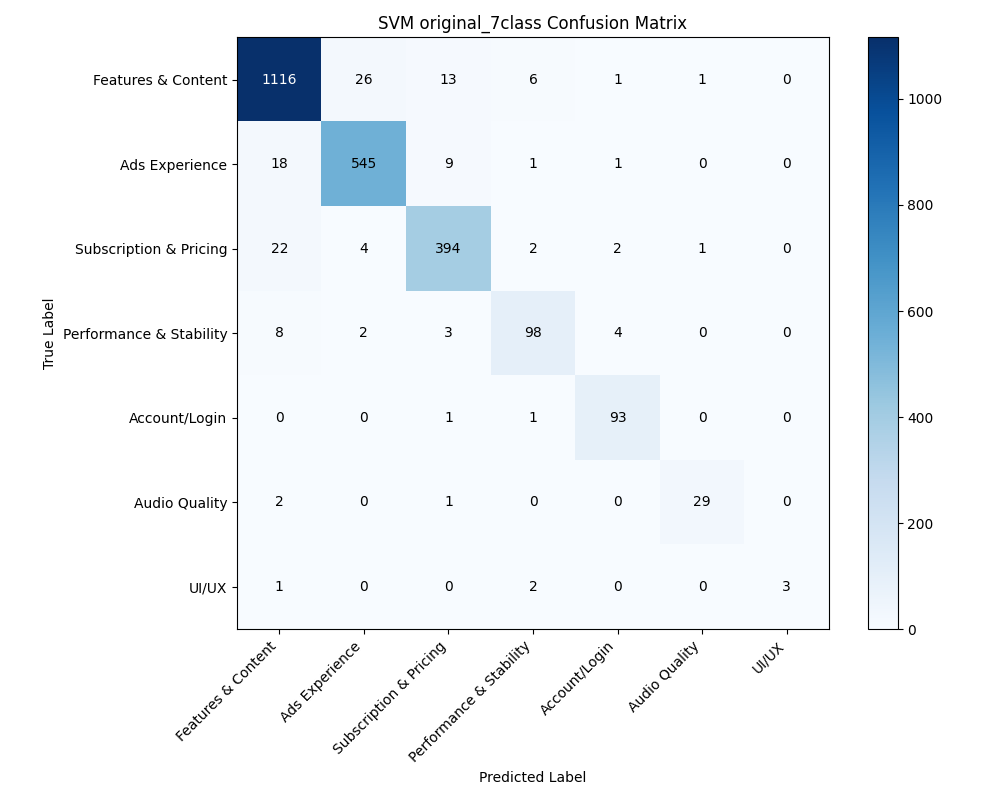

**docs\figures\04_svm\svm_original_7class_class_f1.png**

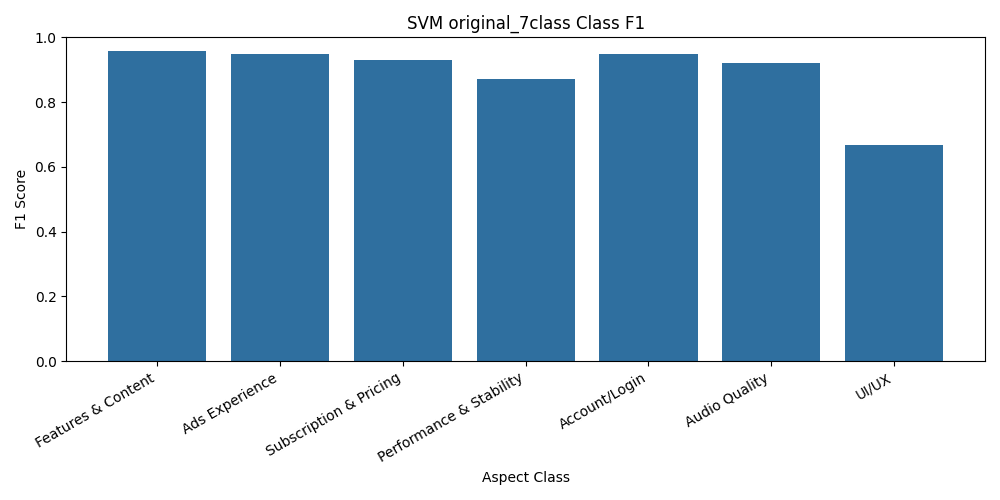

**docs\figures\04_svm\svm_merged_5class_confusion_matrix.png**

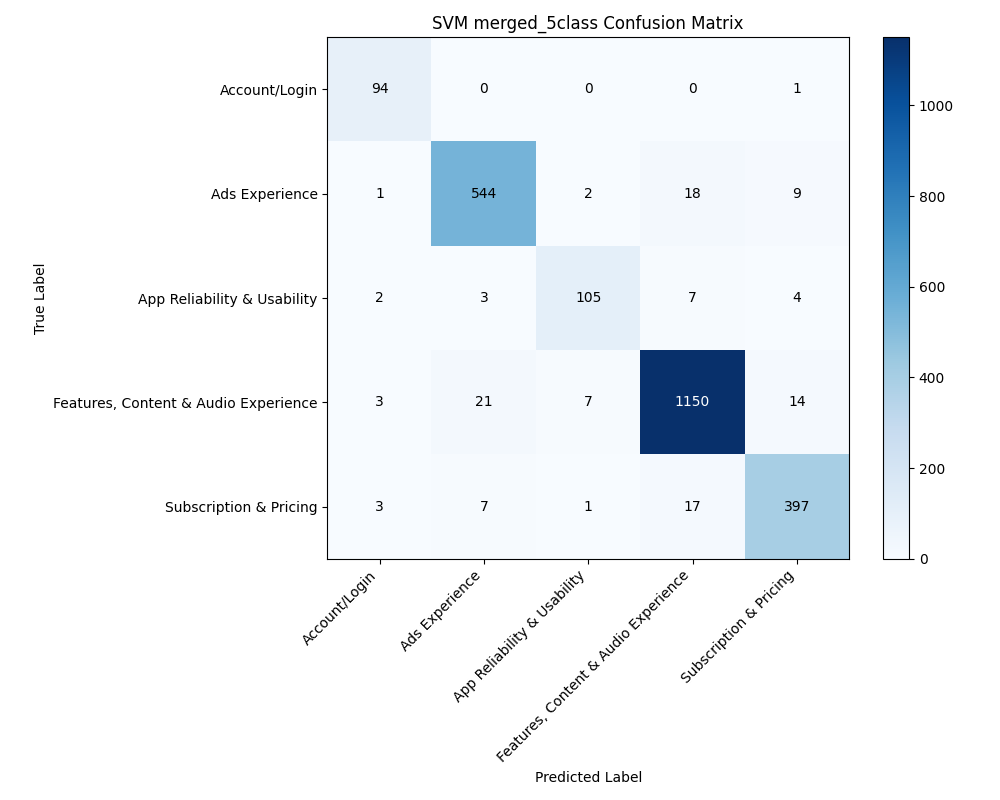

**docs\figures\04_svm\svm_merged_5class_class_f1.png**

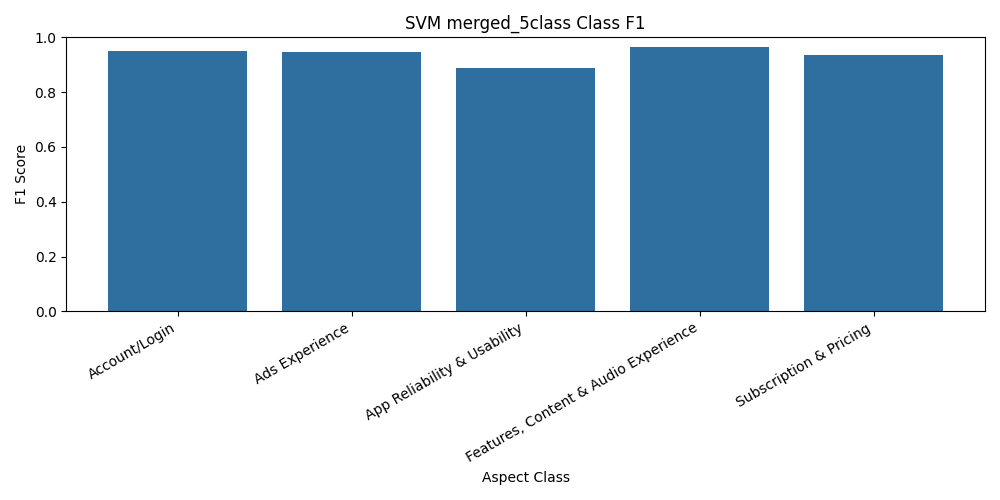

**docs\figures\04_svm\svm_scenario_comparison.png**

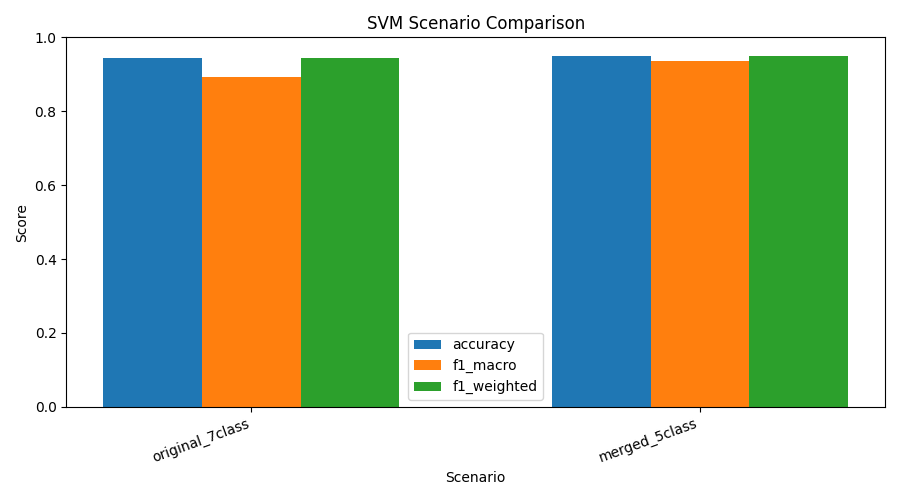

In [6]:
def show_figures(paths: list[Path]) -> None:
    for path in paths:
        if path.exists():
            display(Markdown(f"**{path.relative_to(PROJECT_ROOT)}**"))
            display(Image(filename=str(path)))
        else:
            display(Markdown(f"Missing figure: `{path.relative_to(PROJECT_ROOT)}`"))


show_figures([
    FIG04_DIR / "svm_original_7class_confusion_matrix.png",
    FIG04_DIR / "svm_original_7class_class_f1.png",
    FIG04_DIR / "svm_merged_5class_confusion_matrix.png",
    FIG04_DIR / "svm_merged_5class_class_f1.png",
    FIG04_DIR / "svm_scenario_comparison.png",
])


## Artifact Manifest

SVM model artifacts are local generated files and must remain ignored by Git.


In [7]:
if artifact_manifest:
    display(pd.DataFrame(artifact_manifest["expected_artifacts"]))
    display(Markdown(f"Selected pipeline: `{artifact_manifest['selected_pipeline']}`"))
    display(Markdown(f"Selected label mapping: `{artifact_manifest['selected_label_mapping']}`"))
    display(Markdown(f"Artifact Git policy: `{artifact_manifest['artifact_git_policy']}`"))


,exists_locally,path,size_bytes
0,True,ml-service/saved_models/svm/svm_original_7clas...,4672608
1,True,ml-service/saved_models/svm/svm_original_7clas...,521
2,True,ml-service/saved_models/svm/svm_merged_5class_...,3699008
3,True,ml-service/saved_models/svm/svm_merged_5class_...,482


Selected pipeline: `ml-service/saved_models/svm/svm_merged_5class_pipeline.joblib`

Selected label mapping: `ml-service/saved_models/svm/svm_merged_5class_label_mapping.json`

Artifact Git policy: `ignored_not_committed`

## Next Step

Proceed to Phase 10A: AHP/Fuzzy AHP Criteria and Expert Judgement Design. The criteria should be validated by experts before final pairwise weighting and ranking comparison are implemented.
